In [1]:
countrycode_file_path= r"C:\修論研究\VWT_historical_data\country_list.xlsx"
import pandas as pd
countrycode_df = pd.read_excel(countrycode_file_path)
countrycode_df.head()


,Country name,FAO code,Position,Reporting,Discontinuities,ISO3
0,Afghanistan,2,1,1,NaN,AFG
1,Albania,3,2,1,NaN,ALB
2,Algeria,4,3,1,NaN,DZA
3,American Samoa,5,4,0,NaN,ASM
4,Andorra,6,5,0,NaN,AND


# 輸入総量、輸出総量、netの時系列グラフを描く（国ごと、作物別）

VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_2015.npy

Top 20 net positive (net>0):
    iso3        import        export           net
69   EGY  1.449500e+10  1.617987e+07  1.447882e+10
107  IDN  1.240845e+10  3.941108e+05  1.240806e+10
114  JPN  8.622806e+09  5.271158e+05  8.622279e+09
179  PHL  7.069003e+09  1.579264e+05  7.068845e+09
165  NGA  6.827841e+09  7.921185e+03  6.827833e+09
112  ITA  7.268094e+09  4.831759e+08  6.784918e+09
228  TUR  6.899487e+09  1.297246e+08  6.769762e+09
17   BGD  6.299150e+09  4.980635e+04  6.299100e+09
221  THA  6.205540e+09  2.910650e+06  6.202629e+09
121  KOR  5.998639e+09  2.938534e+03  5.998636e+09
2    DZA  5.947188e+09  1.305992e+04  5.947174e+09
145  MEX  6.504469e+09  1.370693e+09  5.133776e+09
48   CHN  5.082402e+09  5.829778e+06  5.076572e+09
30   BRA  7.927195e+09  2.864255e+09  5.062940e+09
249  YEM  4.423211e+09  9.673107e+04  4.423114e+09
108  IRN  4.350865e+09  1.261041e+08  4.224761e+09
245  VNM  4.2156

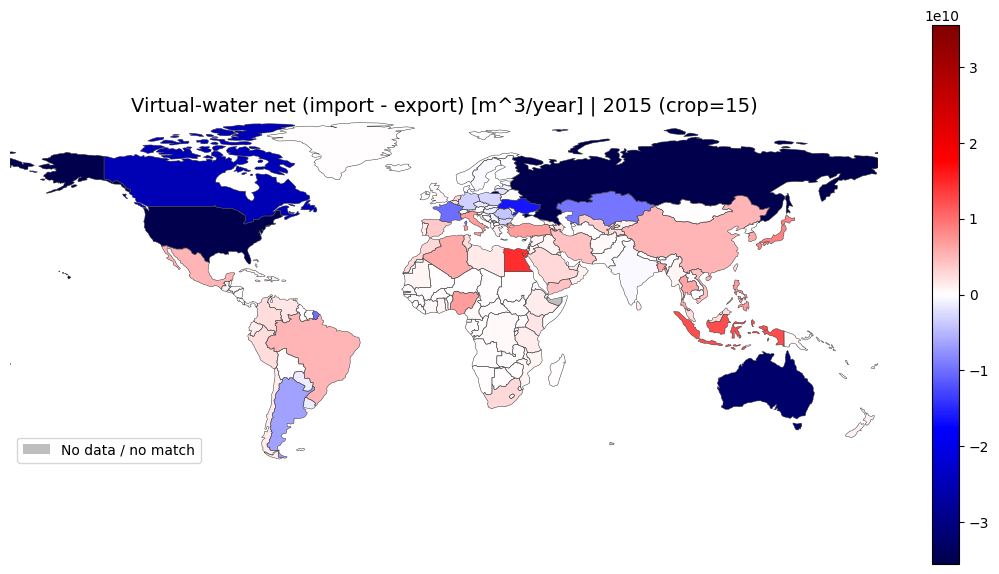

In [13]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def _normalize_zip_shp_path(p: str) -> str:
    # "xxx.zip!yyy.shp" -> "zip://xxx.zip!yyy.shp"
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Natural Earth は国によって ISO_A3 が -99（欠損）になるので、
    ISO_A3 -> ADM0_A3 -> SOV_A3 の順でフォールバックして _iso3 を作る。
    """
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    # 1) primary
    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 2) fallback: ADM0_A3
    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 3) fallback: SOV_A3
    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # cleanup
    world.loc[invalid, "_iso3"] = np.nan

    # 代表的例外（必要なら増やす）
    world["_iso3"] = world["_iso3"].replace({"FR1": "FRA"})

    return world

def plot_vwt_net_import_export_map_debug(
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    top_n_print=20,
    unit="m^3/year",
    cmap="seismic",
    clip_quantile=0.995,
    missing_color="#BEBEBE",
    border_color="#444444",
    border_lw=0.35,
    show_missing_legend=True,
    # --- DEBUG OPTIONS ---
    debug_iso3="FRA",
    print_no_match_samples=30,
    print_df_only_samples=30,
):
    """
    VWTmat: row=exporter, col=importer 前提。
    net = import - export を全世界で計算して、正負込みで地図描画。
    指定ISO3（debug_iso3）の no match / no data 原因を特定するデバッグ出力付き。
    """

    debug_iso3 = str(debug_iso3).strip().upper()

    # -------------------------
    # 1) Load VWT matrix
    # -------------------------
    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    VWTmat = np.load(vwt_path).astype(float)

    if VWTmat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={VWTmat.shape}")

    nrow, ncol = VWTmat.shape
    if nrow != ncol:
        print(f"[WARN] VWTmat is not square: {VWTmat.shape}. row/colの向きを要確認")

    N = min(nrow, ncol)
    VWTmat = VWTmat[:N, :N]

    print("VWTmat shape:", VWTmat.shape)
    print("VWT file:", vwt_path)

    # -------------------------
    # 2) Load country list (ISO3)
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3_raw"] = clN[iso3_col].astype(str)
    clN["_iso3"] = clN["_iso3_raw"].str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA",
        "UK": "GBR",
        "EL": "GRC",
        "SP": "ESP",
        "SW": "SWE",
        "NO": "NOR",
        "JA": "JPN",
        "KO": "KOR",
        "CH": "CHN",   # 注意: CH=Switzerland の可能性もあるので嫌なら消す
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    # -------------------------
    # 3) Compute import/export/net for ALL countries
    # -------------------------
    import_by_country = np.nansum(VWTmat, axis=0)  # col sum
    export_by_country = np.nansum(VWTmat, axis=1)  # row sum
    net = import_by_country - export_by_country

    df_net = pd.DataFrame({
        "iso3": clN["_iso3"].values,
        "import": import_by_country,
        "export": export_by_country,
        "net": net,
    })

    df_pos = df_net[df_net["net"] > 0].sort_values("net", ascending=False)
    df_neg = df_net[df_net["net"] < 0].sort_values("net", ascending=True)

    print(f"\nTop {top_n_print} net positive (net>0):")
    print(df_pos.head(top_n_print)[["iso3", "import", "export", "net"]])

    print(f"\nTop {top_n_print} net negative (net<0):")
    print(df_neg.head(top_n_print)[["iso3", "import", "export", "net"]])

    # -------------------------
    # 4) Load world map（★修正点：robust iso3 key）
    # -------------------------
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    # -------------------------
    # 5) Merge
    # -------------------------
    m = world.merge(df_net, left_on="_iso3", right_on="iso3", how="left")

    # -------------------------
    # 5.5) DEBUG PRINTS
    # -------------------------
    print("\n" + "=" * 70)
    print(f"[DEBUG] Investigate ISO3 = {debug_iso3}")
    print("=" * 70)

    # A) world側に debug_iso3 があるか？
    print(f"[DEBUG] world has {debug_iso3}? ->", (world["_iso3"] == debug_iso3).any())
    if (world["_iso3"] == debug_iso3).any():
        w_rows = world[world["_iso3"] == debug_iso3]
        cols = [c for c in ["NAME", "NAME_EN", "ADMIN", "SOVEREIGNT", "ISO_A3", "ADM0_A3", "SOV_A3", "_iso3"] if c in w_rows.columns]
        print("[DEBUG] world rows for debug_iso3:")
        print(w_rows[cols].head(10))
    else:
        # debug_iso3 が world に無いなら、名前で近い行を探す（debug_iso3に応じたキーワードは推測できないので、代表列を一応表示）
        for name_col in ["NAME", "ADMIN", "SOVEREIGNT", "NAME_EN"]:
            if name_col in world.columns:
                # とりあえず "France" 固定じゃなく、debug_iso3 を出せるだけ出す
                # （国名はISO3からは自動で出せないので、ここは人間が見て判断する用途）
                pass
        print("[DEBUG] world does not contain that ISO3 key. Likely ISO_A3 was -99 and fallback still didn't map, or needs WORLD_FIX.")

    # B) df_net側に debug_iso3 があるか？
    print(f"[DEBUG] df_net has {debug_iso3}? ->", (df_net["iso3"] == debug_iso3).any())
    if (df_net["iso3"] == debug_iso3).any():
        print("[DEBUG] df_net row for debug_iso3:")
        print(df_net[df_net["iso3"] == debug_iso3][["iso3", "import", "export", "net"]].head(5))
        raw_rows = clN[clN["_iso3"] == debug_iso3][["_iso3_raw", "_iso3"]].head(10)
        print("[DEBUG] country_list raw->clean for debug_iso3:")
        print(raw_rows)
    else:
        candidates = clN[clN["_iso3"].str.contains(debug_iso3[:2], na=False)][["_iso3_raw", "_iso3"]].head(30)
        print(f"[DEBUG] country_list candidates containing '{debug_iso3[:2]}':")
        print(candidates)

    # C) merge後、debug_iso3 の net が NaN か？
    m_dbg = m[m["_iso3"] == debug_iso3][["_iso3", "iso3", "net", "import", "export"]]
    print("[DEBUG] merged rows for debug_iso3:")
    print(m_dbg.head(10))
    if len(m_dbg) == 0:
        print("[DEBUG] merged has no row for debug_iso3 (world側にそのISO3が存在しない可能性)")
    else:
        if m_dbg["net"].isna().all():
            print("[DEBUG] merged net is NaN -> KEY MISMATCH (world has iso but df_net lacks matching iso3)")

    # D) worldにはあるがdf_netに無い（=no match）のISO3
    no_match = m[m["_iso3"].notna() & m["net"].isna()][["_iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample world-iso3 but missing in df_net (no match): n={len(no_match)}")
    print(no_match.head(print_no_match_samples).to_string(index=False))

    # E) df_netにはあるがworldに無いISO3
    net_only = df_net[~df_net["iso3"].isin(world["_iso3"].dropna())][["iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample df_net iso3 but missing in world: n={len(net_only)}")
    print(net_only.head(print_df_only_samples).to_string(index=False))

    print("=" * 70 + "\n")

    # -------------------------
    # 6) Decide symmetric color scale around 0
    # -------------------------
    vals = m["net"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("net の有効値が無い（マージ失敗 or netが全部NaN）。ISO3対応を確認して。")

    absvals = np.abs(vals)

    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1]. e.g., 0.995")
        vmax = float(np.nanquantile(absvals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(absvals))
    else:
        vmax = float(np.nanmax(absvals))

    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # -------------------------
    # 7) Plot
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(
        f"Virtual-water net (import - export) [{unit}] | {year} (crop={crop})",
        fontsize=14
    )

    # 欠損国をはっきりグレー
    m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)

    # netがある国だけカラーマップ
    has = np.isfinite(m["net"].astype(float))
    m.loc[has].plot(
        ax=ax,
        column="net",
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        legend=True,
        zorder=2
    )

    # 国境線を上から
    m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

    if show_missing_legend:
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match")],
            loc="lower left",
            frameon=True
        )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return df_net, m


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

df_net, merged_map = plot_vwt_net_import_export_map_debug(
    year=2015,
    crop=15,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    cmap="seismic",
    clip_quantile=0.995,
    missing_color="#BEBEBE",
    border_color="#444444",
    border_lw=0.35,
    debug_iso3="FRA",
)

# netのアニメーションをつくる

N: 255
world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)
Global scale: vmax=3.59591e+10 (TwoSlopeNorm, clip_quantile=0.995)


Saved GIF: C:\修論研究\VWT_historical_data\net_crop15_1986_2016.gif


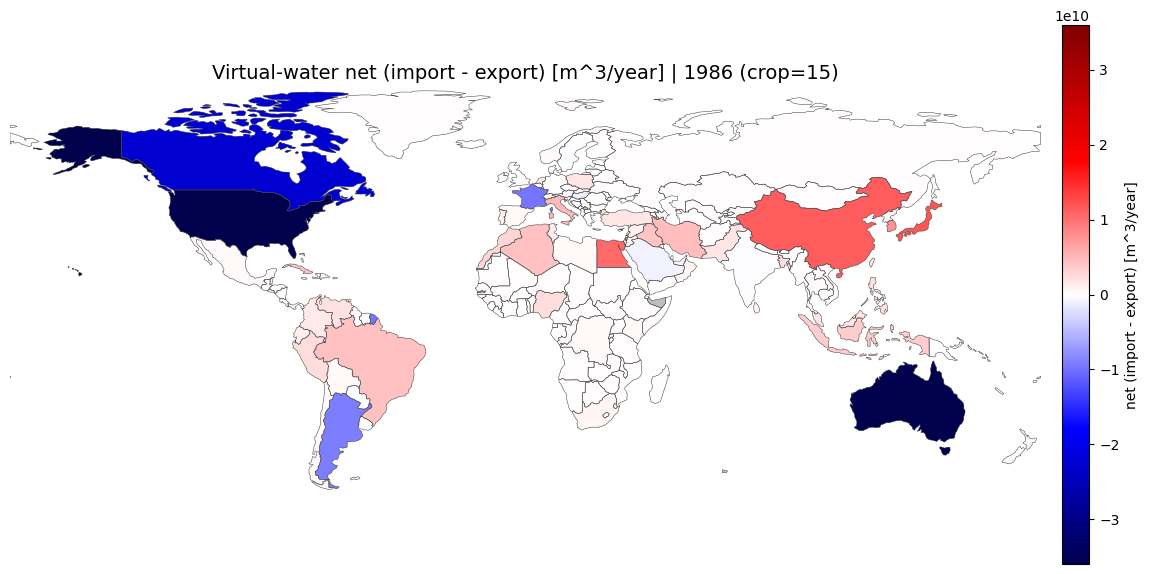

In [16]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation

def _normalize_zip_shp_path(p: str) -> str:
    """
    gpd.read_file() が読めるように、"xxx.zip!yyy.shp" を "zip://xxx.zip!yyy.shp" に寄せる。
    すでに zip:// が付いてたらそのまま。
    """
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Natural Earth は国によって ISO_A3 が -99（欠損）になるので、
    ISO_A3 -> ADM0_A3 -> SOV_A3 の順でフォールバックして _iso3 を作る。
    """
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    # 1) primary: ISO_A3
    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 2) fallback: ADM0_A3
    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 3) fallback: SOV_A3
    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # cleanup
    world.loc[invalid, "_iso3"] = np.nan

    # 代表的例外（必要なら増やす）
    world["_iso3"] = world["_iso3"].replace({
        "FR1": "FRA",
        # "XKX": "KOS",  # Kosovo をどう扱うかは好み（NEの版による）
    })

    return world

def animate_vwt_net_import_export(
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    unit="m^3/year",
    fps: int = 6,
    interval_ms: int | None = None,
    out_mp4: str | None = None,
    out_gif: str | None = None,
    dpi: int = 150,
    # 可視化設定
    cmap: str = "seismic",
    clip_quantile: float | None = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
):
    """
    - crop は固定
    - year_start..year_end をアニメ化
    - net = import - export を正負込みで描画
    - カラーバーは全期間で固定スケール（global vmax）: TwoSlopeNorm(-vmax..+vmax, center=0)
    """
    years = list(range(int(year_start), int(year_end) + 1))
    if interval_ms is None:
        interval_ms = int(1000 / max(1, fps))

    # -------------------------
    # 1) country_list (ISO3)
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    # N はVWTのサイズに合わせたいので、まず最初の年を読んでN確定
    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    N = vwt0.shape[0]
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")

    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA",
        "UK": "GBR",
        "EL": "GRC",
        "SP": "ESP",
        "SW": "SWE",
        "NO": "NOR",
        "JA": "JPN",
        "KO": "KOR",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    print("N:", N)

    # -------------------------
    # 2) world map load（★修正点：robust iso3 key）
    # -------------------------
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    # -------------------------
    # 3) preload net (all years) + global vmax
    # -------------------------
    net_by_year = {}
    global_abs_vals = []

    for y in years:
        vwt_path = vwt_npy_template.format(crop=crop, year=y)
        VWTmat = np.load(vwt_path).astype(float)
        if VWTmat.shape[0] != N or VWTmat.shape[1] != N:
            raise ValueError(f"年{y}のVWTサイズが一致しない: {VWTmat.shape} (expected {N}x{N})")

        import_sum = np.nansum(VWTmat, axis=0)  # col sum
        export_sum = np.nansum(VWTmat, axis=1)  # row sum
        net = (import_sum - export_sum).astype(float)

        net_by_year[y] = net

        vv = net[np.isfinite(net)]
        if vv.size > 0:
            global_abs_vals.append(np.abs(vv))

    if len(global_abs_vals) == 0:
        raise ValueError("[ERROR] 全年で net の有限値が1つも無い（データ/読み込み要確認）")

    global_abs_vals = np.concatenate(global_abs_vals)

    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1]. e.g., 0.995")
        vmax = float(np.nanquantile(global_abs_vals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(global_abs_vals))
    else:
        vmax = float(np.nanmax(global_abs_vals))

    if vmax <= 0 or not np.isfinite(vmax):
        vmax = 1.0

    print(f"Global scale: vmax={vmax:g} (TwoSlopeNorm, clip_quantile={clip_quantile})")

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # -------------------------
    # 4) figure & fixed colorbar
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"net (import - export) [{unit}]")

    # -------------------------
    # 5) animation update
    # -------------------------
    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        ax.set_title(
            f"Virtual-water net (import - export) [{unit}] | {y} (crop={crop})",
            fontsize=14
        )

        net = net_by_year[y]
        df = pd.DataFrame({"iso3": clN["_iso3"].values, "net": net})

        m = world.merge(df, left_on="_iso3", right_on="iso3", how="left")

        # base: no data/no match
        m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none")

        # net exists
        has = np.isfinite(m["net"].astype(float))
        if has.any():
            m.loc[has].plot(
                ax=ax,
                column="net",
                cmap=cmap,
                norm=norm,          # ★固定スケール
                linewidth=0.0,
                edgecolor="none",
                legend=False,
            )

        # borders
        m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw)

        # ★ガタガタ防止：座標系を毎フレーム固定
        ax.set_aspect("equal")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=len(years),
        interval=interval_ms,
        blit=False
    )

    # -------------------------
    # 6) save (optional)
    # -------------------------
    if out_mp4:
        anim.save(
            out_mp4,
            writer="ffmpeg",
            fps=fps,
            dpi=dpi,
            savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05},
        )
        print("Saved MP4:", out_mp4)

    if out_gif:
        anim.save(
            out_gif,
            writer="pillow",
            fps=fps,
            dpi=dpi,
            savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0.05},
        )
        print("Saved GIF:", out_gif)

    # plt.show()
    return anim


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

anim = animate_vwt_net_import_export(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\net_crop15_1986_2016.gif",
    cmap="seismic",
    clip_quantile=0.995,
)